# Objetivo do trabalho
Uso da VGG16 para detecção de cancer de intestino

### Download do LC25000 através do kaggle

In [1]:
from google.colab import files
!pip install -q kaggle

In [2]:
def upload_kaggle_dataset_in_colab():
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

def unzip_kaggle_dataset_in_colab():
    !kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
    !unzip -q lung-and-colon-cancer-histopathological-images.zip

def unzip_support_functions_in_colab():
    !kaggle datasets download -d gabrielcruzvazsantos/colon-detection-support-functions
    !unzip -q colon-detection-support-functions.zip


def get_kaggle_dataset_in_colab():
    upload_kaggle_dataset_in_colab()
    unzip_kaggle_dataset_in_colab()
    unzip_support_functions_in_colab()

In [3]:
get_kaggle_dataset_in_colab()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.74G/1.76G [00:09<00:00, 250MB/s]
100% 1.76G/1.76G [00:09<00:00, 193MB/s]
Dataset URL: https://www.kaggle.com/datasets/gabrielcruzvazsantos/colon-detection-support-functions
License(s): unknown
  0% 0.00/4.00k [00:00<?, ?B/s]
100% 4.00k/4.00k [00:00<00:00, 13.3MB/s]


## Uso de código externo
Esse notebook foi preparado para utilizar código modular python externo que, para seu devido funcionamento, precisa ser feito o upload via

In [4]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders
from train_and_test_model import train_model, test_model


In [5]:
import torch
import torchvision
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns


### Datasets e dataLoader

In [6]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 28624.42it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [7]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test)

### Modelo e treinamento
- VGG16
- Canais de entrada - imagem RGB: 3
- Saída - Problema de classificação binária: 2
- Taxa de aprendizado: 1e-3

In [12]:
in_channels = 3
output_features = 2
learning_rate = 1e-3

In [ ]:
model = torchvision.models.vgg16(num_classes=output_features)

In [ ]:
model = model.to("cuda")

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer)

Epoch 1: Train Loss = 7.3288 | Val Loss = 0.6932
Epoch 2: Train Loss = 0.6940 | Val Loss = 0.6931
Epoch 3: Train Loss = 0.6936 | Val Loss = 0.6932
Epoch 4: Train Loss = 0.6937 | Val Loss = 0.6931
Epoch 5: Train Loss = 0.6935 | Val Loss = 0.6931
Epoch 6: Train Loss = 0.6936 | Val Loss = 0.6931
Epoch 7: Train Loss = 0.6935 | Val Loss = 0.6931
Epoch 8: Train Loss = 0.6935 | Val Loss = 0.6931
Epoch 9: Train Loss = 0.6935 | Val Loss = 0.6931
Epoch 10: Train Loss = 0.6935 | Val Loss = 0.6931


#### imprimindo resultados do treinamento e validação

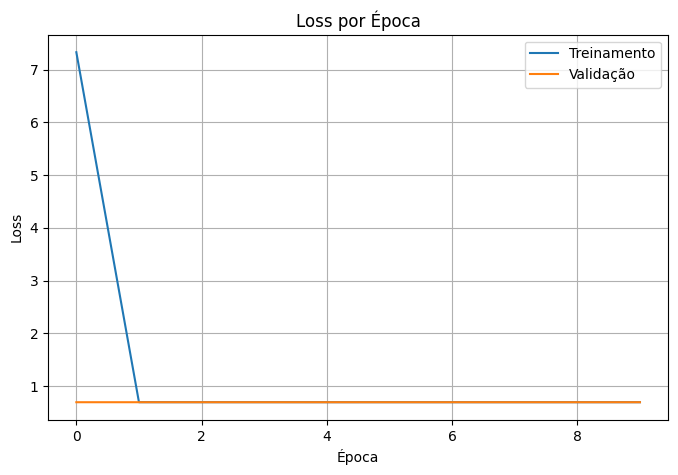

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Testando modelo

In [ ]:
acc, precision, recall, f1, cm = test_model(best_model, "cuda", dataloader_test)

Acurácia: 0.5000
Precisão (weighted): 0.2500
Recall (weighted): 0.5000
F1-score (weighted): 0.3333
Matriz de Confusão:
[[   0 1000]
 [   0 1000]]


In [ ]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.5    │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.25   │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.5    │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.3333 │
╘═════════════════════╧═════════╛


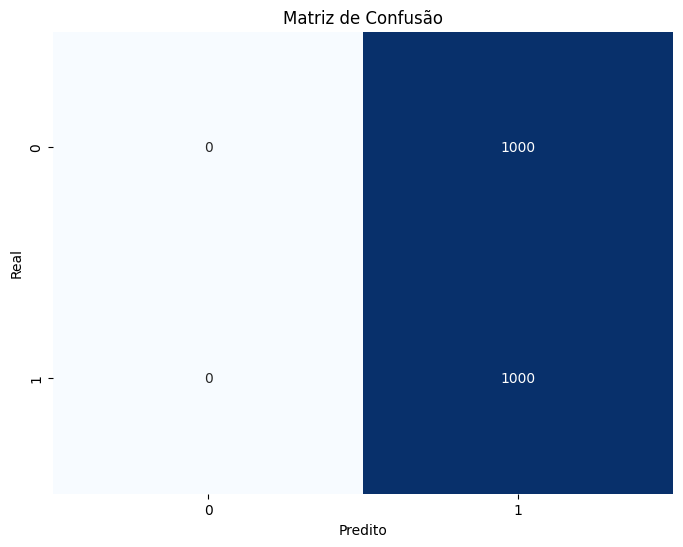

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Tentativa de ajuste: Modificação parâmetro de aprendizagem

In [ ]:
new_model = torchvision.models.vgg16(num_classes=output_features)
new_learning_rate = 1e-2

In [ ]:
new_model = new_model.to("cuda")

In [ ]:
train_losses, val_losses, best_model = train_model(new_model, dataloader_train, dataloader_validation, learning_rate=new_learning_rate)

Epoch 1: Train Loss = 407552384031.9044 | Val Loss = 0.6985
Epoch 2: Train Loss = 0.6985 | Val Loss = 0.6946
Epoch 3: Train Loss = 0.6965 | Val Loss = 0.6943
Epoch 4: Train Loss = 0.6962 | Val Loss = 0.6943
Epoch 5: Train Loss = 0.6960 | Val Loss = 0.6943
Epoch 6: Train Loss = 0.6960 | Val Loss = 0.6943
Epoch 7: Train Loss = 0.6960 | Val Loss = 0.6943
Epoch 8: Train Loss = 0.6960 | Val Loss = 0.6943
Epoch 9: Train Loss = 0.6960 | Val Loss = 0.6943
Epoch 10: Train Loss = 0.6960 | Val Loss = 0.6943


#### Resultado: Continuou não convergindo mesmo com uma learning_rate diferença

### Alteração do optimizer com weight_decay
Weight_decay acresecenta uma perda na função de custo, o que evita sua "explosão"

In [ ]:
learning_rate = 1e-4

In [ ]:
wd_model = torchvision.models.vgg16(num_classes=output_features)
wd_model = wd_model.to("cuda")

In [ ]:
wd_optimizer = torch.optim.Adam(wd_model.parameters(), lr=learning_rate, weight_decay=1e-5)

In [ ]:
train_losses, val_losses, best_model = train_model(wd_model, dataloader_train, dataloader_validation, optimizer=wd_optimizer)

Epoch 1: Train Loss = 0.6965 | Val Loss = 0.6931
Epoch 2: Train Loss = 0.6935 | Val Loss = 0.6931
Epoch 3: Train Loss = 0.6935 | Val Loss = 0.6931
Epoch 4: Train Loss = 0.6936 | Val Loss = 0.6931
Epoch 5: Train Loss = 0.6937 | Val Loss = 0.6931


#### Resultado: Continuou não convergindo mesmo com o decaimento de peso

### Utilização de Tranfer-Learning
Ao contrário da AlexNet, a VGG16 é uma rede muito mais profunda, com mais de o dobro de parâmetros (138M vs 60M), o que dificulta a convergência dos parâmetros do zero.

In [8]:
transfer_model = torchvision.models.vgg16(pretrained=True)
transfer_model.classifier

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:07<00:00, 78.3MB/s]


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [16]:
transfer_model = transfer_model.to("cuda")

In [10]:
for param in transfer_model.features.parameters():
    param.requires_grad = False

In [13]:
transfer_model.classifier[6] = torch.nn.Linear(in_features=4096, out_features=output_features)
transfer_model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)

In [14]:
transfer_optimizer = torch.optim.Adam( filter(lambda p: p.requires_grad, transfer_model.parameters()),lr=learning_rate, weight_decay=1e-5)

In [ ]:
train_losses, val_losses, best_model = train_model(transfer_model, dataloader_train, dataloader_validation, optimizer=transfer_optimizer)

Epoch 1: Train Loss = 6.0405 | Val Loss = 0.3999
Epoch 2: Train Loss = 8.1716 | Val Loss = 0.9073
Epoch 3: Train Loss = 13.4473 | Val Loss = 0.3446
Epoch 4: Train Loss = 8.1254 | Val Loss = 1.3187
Epoch 5: Train Loss = 10.7724 | Val Loss = 1.6351
Epoch 6: Train Loss = 14.4042 | Val Loss = 5.2200
Epoch 7: Train Loss = 12.0955 | Val Loss = 2.4543
